In [11]:
import kagglehub
import os

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Dataset Path:", path)

csv_file = os.path.join(path, "Mall_Customers.csv")
df = pd.read_csv(csv_file)
df.head()

Dataset Path: C:\Users\ganes\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [12]:
#  Basic Info
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Statistical Summary ===')
print(df.describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Statistical Summary ===
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721      

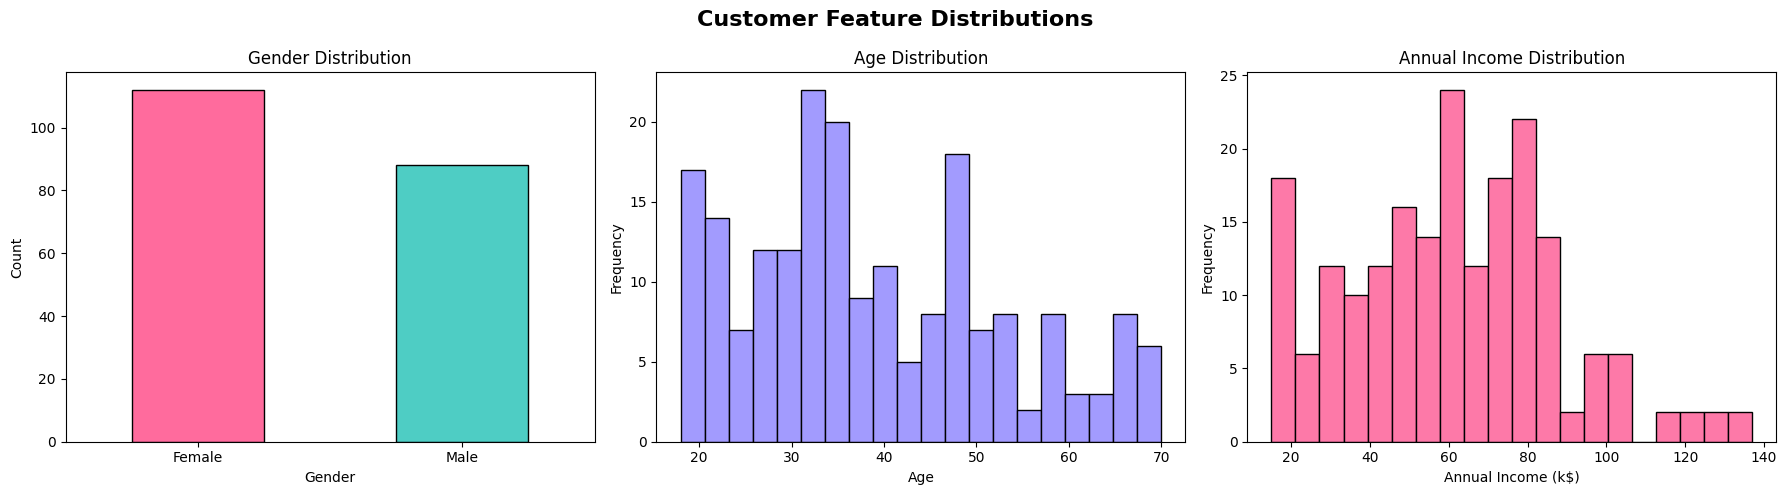

✅ Plot saved: eda_distributions.png


In [14]:
# Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Feature Distributions', fontsize=16, fontweight='bold')

# Gender count
df['Gender'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#FF6B9D','#4ECDC4'],
    edgecolor='black'
)

axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Age
axes[1].hist(df['Age'], bins=20, color='#A29BFE', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

# Annual Income (FIXED)
axes[2].hist(df['Annual Income (k$)'], bins=20, color='#FD79A8', edgecolor='black')
axes[2].set_title('Annual Income Distribution')
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved: eda_distributions.png")

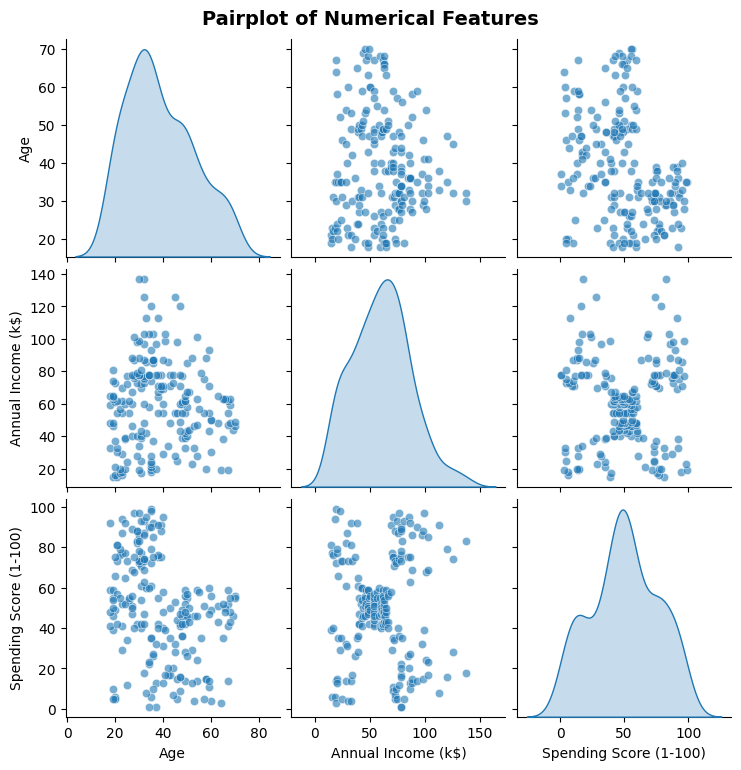

✅ Plot saved: pairplot.png


In [16]:
# ----- 3c. Pairplot -----
sns.pairplot(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot saved: pairplot.png')

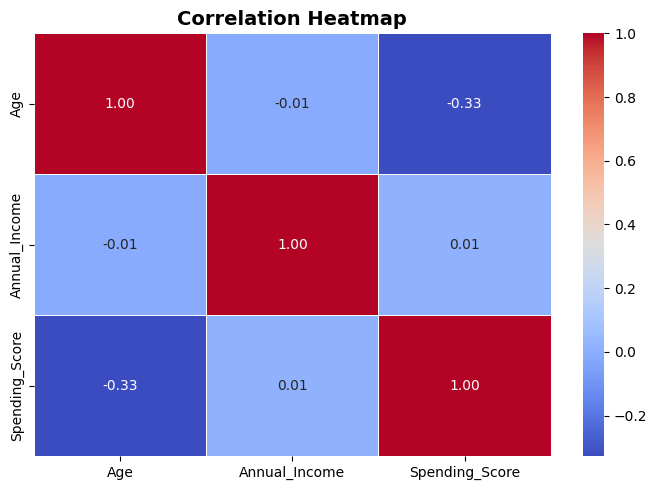

✅ Plot saved: correlation_heatmap.png


In [20]:
# ----- 3d. Correlation Heatmap -----
plt.figure(figsize=(7,5))

corr = df[['Age','Annual_Income','Spending_Score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved: correlation_heatmap.png")

In [21]:
# Select features most relevant to purchase history
# Annual_Income  = earning capacity
# Spending_Score = purchasing behavior
X = df[['Annual_Income', 'Spending_Score']].values

print('Selected Features:')
print('  - Annual_Income')
print('  - Spending_Score')
print(f'\nFeature matrix shape: {X.shape}')

Selected Features:
  - Annual_Income
  - Spending_Score

Feature matrix shape: (200, 2)


In [22]:
# Scale the features (important for K-Means — distance-based algorithm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before Scaling (first 5 rows):')
print(X[:5])
print('\nAfter Scaling (first 5 rows):')
print(X_scaled[:5].round(4))
print('\n✅ Features scaled successfully using StandardScaler!')

Before Scaling (first 5 rows):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]

After Scaling (first 5 rows):
[[-1.739  -0.4348]
 [-1.739   1.1957]
 [-1.7008 -1.7159]
 [-1.7008  1.0404]
 [-1.6627 -0.396 ]]

✅ Features scaled successfully using StandardScaler!


In [24]:
# ----- 5a. Compute Inertia & Silhouette for K = 2 to 10 -----
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f'K={k}  |  Inertia: {kmeans.inertia_:8.2f}  |  Silhouette Score: {score:.4f}')

K=2  |  Inertia:   269.69  |  Silhouette Score: 0.3213
K=3  |  Inertia:   157.70  |  Silhouette Score: 0.4666
K=4  |  Inertia:   108.92  |  Silhouette Score: 0.4939
K=5  |  Inertia:    65.57  |  Silhouette Score: 0.5547
K=6  |  Inertia:    55.06  |  Silhouette Score: 0.5399
K=7  |  Inertia:    44.86  |  Silhouette Score: 0.5281
K=8  |  Inertia:    37.23  |  Silhouette Score: 0.4552
K=9  |  Inertia:    32.39  |  Silhouette Score: 0.4571
K=10  |  Inertia:    29.98  |  Silhouette Score: 0.4432


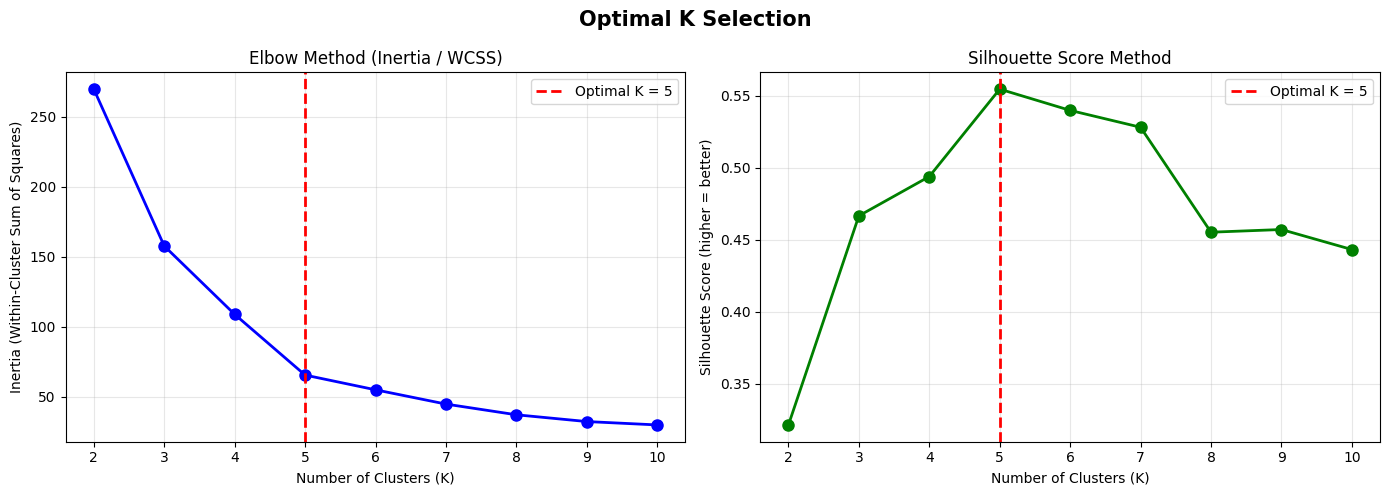

✅ Plot saved: optimal_k.png

🎯 Chosen Optimal K = 5
   Reason: Clear elbow at K=5 and good silhouette score


In [25]:
# ----- 5b. Plot Elbow Curve + Silhouette Scores -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=15, fontweight='bold')

# Elbow Curve
axes[0].plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K = 5')
axes[0].set_title('Elbow Method (Inertia / WCSS)', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Scores
axes[1].plot(K_range, silhouette_scores, 'go-', markersize=8, linewidth=2)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K = 5')
axes[1].set_title('Silhouette Score Method', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot saved: optimal_k.png')
print(f'\n🎯 Chosen Optimal K = 5')
print('   Reason: Clear elbow at K=5 and good silhouette score')

In [26]:
# Train K-Means with optimal K=5
OPTIMAL_K = 5

kmeans = KMeans(
    n_clusters = OPTIMAL_K,
    init       = 'k-means++',   # Smart centroid initialization
    random_state = 42,
    n_init     = 10             # Run 10 times, pick best
)
kmeans.fit(X_scaled)

# Attach cluster labels back to dataframe
df['Cluster'] = kmeans.labels_

print(f'✅ K-Means model trained with K = {OPTIMAL_K}')
print(f'\n📊 Model Metrics:')
print(f'   Inertia (WCSS)    : {kmeans.inertia_:.2f}')
print(f'   Silhouette Score  : {silhouette_score(X_scaled, kmeans.labels_):.4f}')
print(f'\n👥 Customers per Cluster:')
print(df['Cluster'].value_counts().sort_index().to_string())

✅ K-Means model trained with K = 5

📊 Model Metrics:
   Inertia (WCSS)    : 65.57
   Silhouette Score  : 0.5547

👥 Customers per Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23


In [27]:
# Preview labelled data
print('\nSample rows with Cluster labels:')
print(df.head(15).to_string())


Sample rows with Cluster labels:
    CustomerID  Gender  Age  Annual_Income  Spending_Score  Cluster
0            1    Male   19             15              39        4
1            2    Male   21             15              81        2
2            3  Female   20             16               6        4
3            4  Female   23             16              77        2
4            5  Female   31             17              40        4
5            6  Female   22             17              76        2
6            7  Female   35             18               6        4
7            8  Female   23             18              94        2
8            9    Male   64             19               3        4
9           10  Female   30             19              72        2
10          11    Male   67             19              14        4
11          12  Female   35             19              99        2
12          13  Female   58             20              15        4
13          14

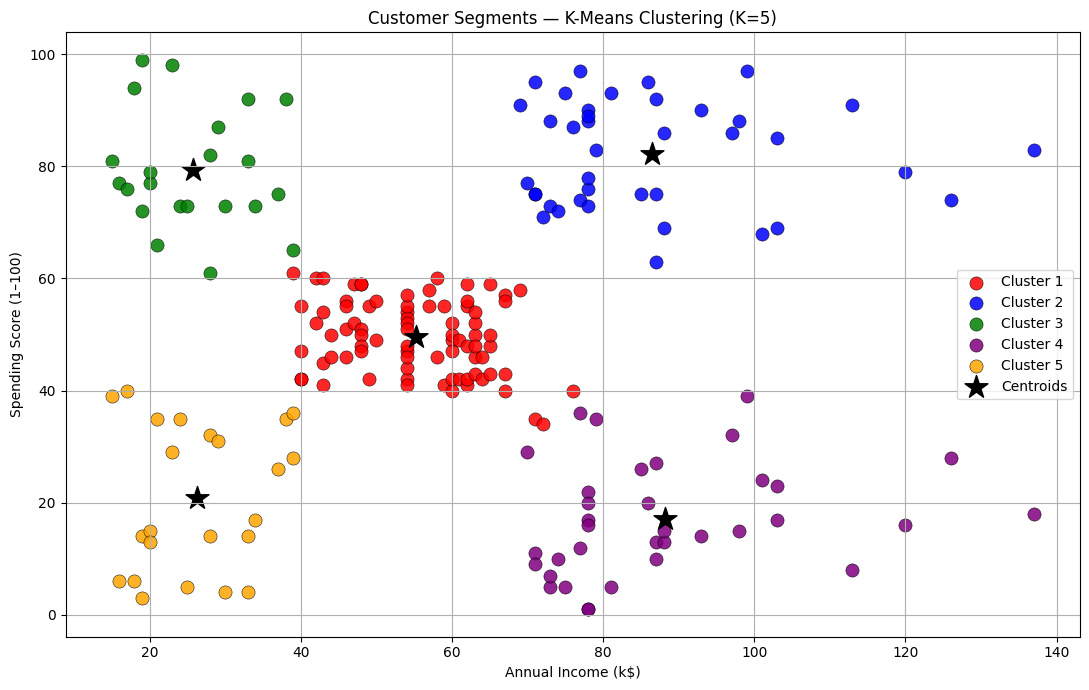

✅ Plot saved: customer_clusters_2D.png


In [36]:
# Define colors and labels
COLORS = ['red','blue','green','purple','orange']

CLUSTER_NAMES = [
    'Cluster 1',
    'Cluster 2',
    'Cluster 3',
    'Cluster 4',
    'Cluster 5'
]

#----- 7a. 2D Scatter Plot -----
plt.figure(figsize=(11,7))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]

    plt.scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        s=90,
        color=COLORS[i],
        label=CLUSTER_NAMES[i],
        alpha=0.85,
        edgecolors='black',
        linewidth=0.4
    )

# Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    c='black',
    marker='*',
    label='Centroids'
)

plt.title('Customer Segments — K-Means Clustering (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('customer_clusters_2D.png', dpi=150)

plt.show()

print("✅ Plot saved: customer_clusters_2D.png")

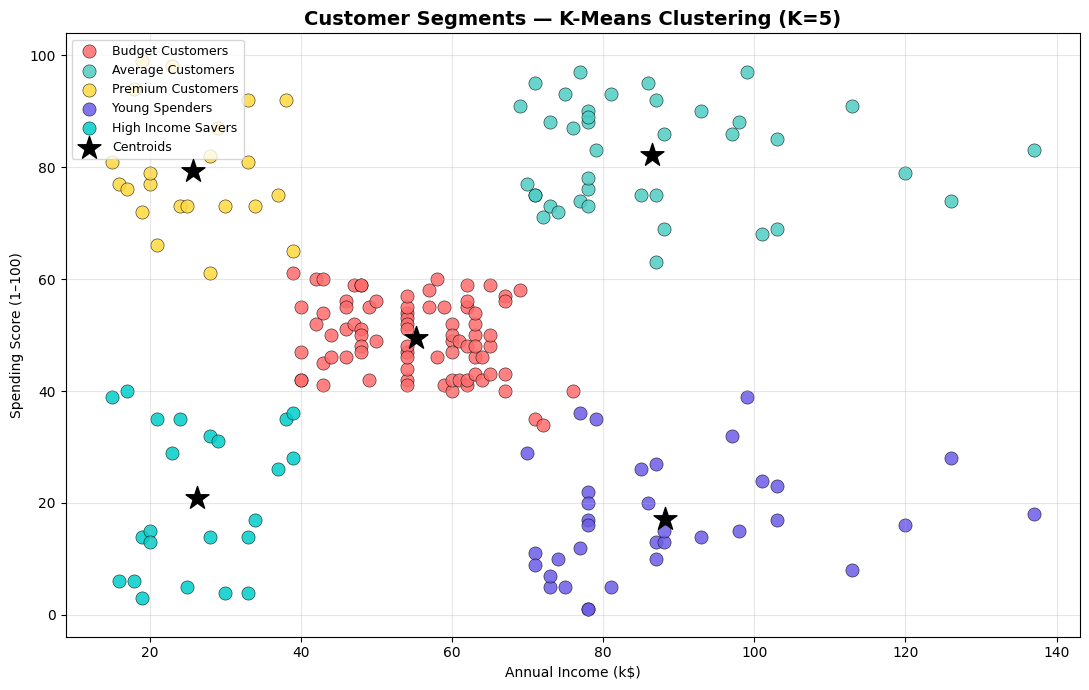

✅ Plot saved: customer_clusters_2D.png


In [29]:
# Define colors and labels
COLORS = ['#FF6B6B','#4ECDC4','#FFD93D','#6C5CE7','#00CEC9']

CLUSTER_NAMES = [
    'Budget Customers',
    'Average Customers',
    'Premium Customers',
    'Young Spenders',
    'High Income Savers'
]

# ----- 7a. 2D Scatter Plot -----
plt.figure(figsize=(11,7))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]

    plt.scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        s=90,
        color=COLORS[i],
        label=CLUSTER_NAMES[i],
        alpha=0.85,
        edgecolors='black',
        linewidth=0.4
    )

# Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    c='black',
    marker='*',
    zorder=6,
    label='Centroids'
)

plt.title('Customer Segments — K-Means Clustering (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')

plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('customer_clusters_2D.png', dpi=150, bbox_inches='tight')

plt.show()

print("✅ Plot saved: customer_clusters_2D.png")

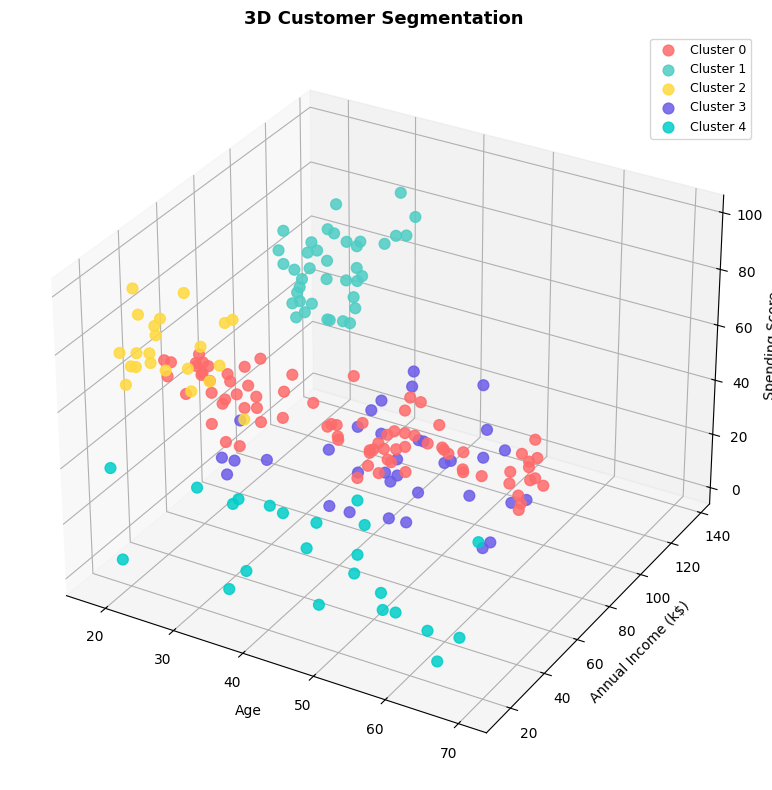

✅ Plot saved: customer_clusters_3D.png


In [30]:
#  3D Scatter Plot (Age + Income + Spending)
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(
        cluster_data['Age'],
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        s=60, color=COLORS[i],
        label=f'Cluster {i}',
        alpha=0.85
    )

ax.set_xlabel('Age', fontsize=10)
ax.set_ylabel('Annual Income (k$)', fontsize=10)
ax.set_zlabel('Spending Score', fontsize=10)
ax.set_title('3D Customer Segmentation', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('customer_clusters_3D.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: customer_clusters_3D.png')

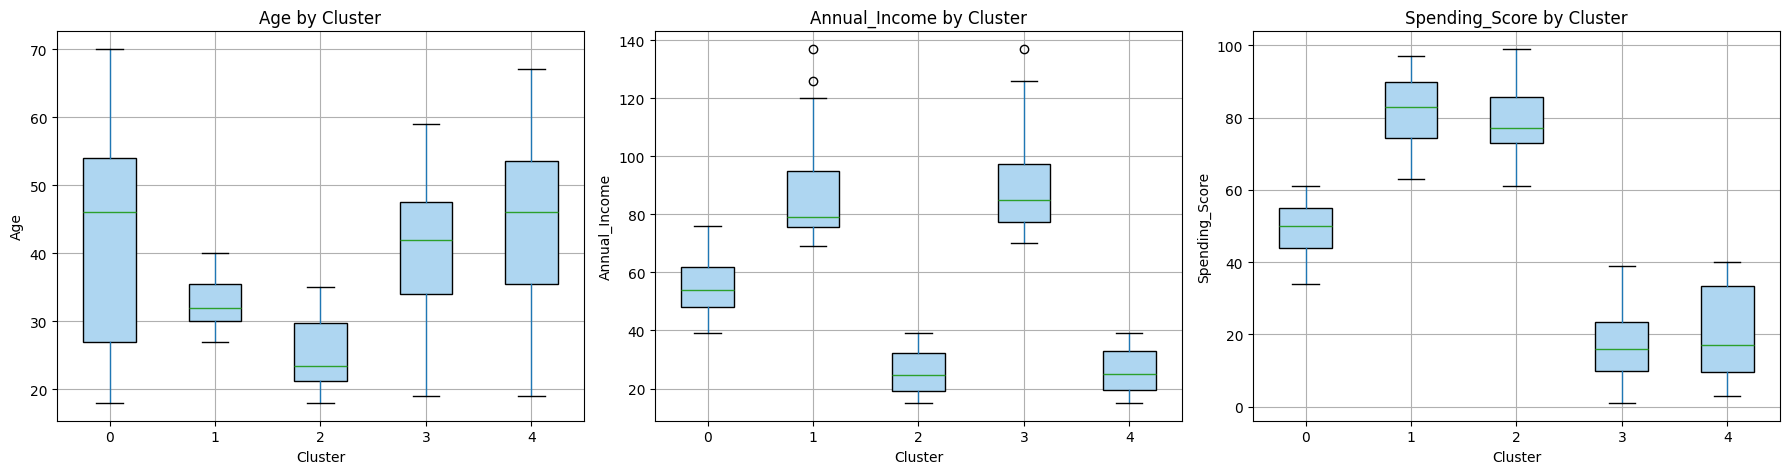

✅ Plot saved: cluster_boxplots.png


In [31]:
#  Boxplots per Cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distribution per Cluster', fontsize=14, fontweight='bold')

for idx, feature in enumerate(['Age', 'Annual_Income', 'Spending_Score']):
    df.boxplot(column=feature, by='Cluster', ax=axes[idx],
               patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    axes[idx].set_title(f'{feature} by Cluster')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: cluster_boxplots.png')

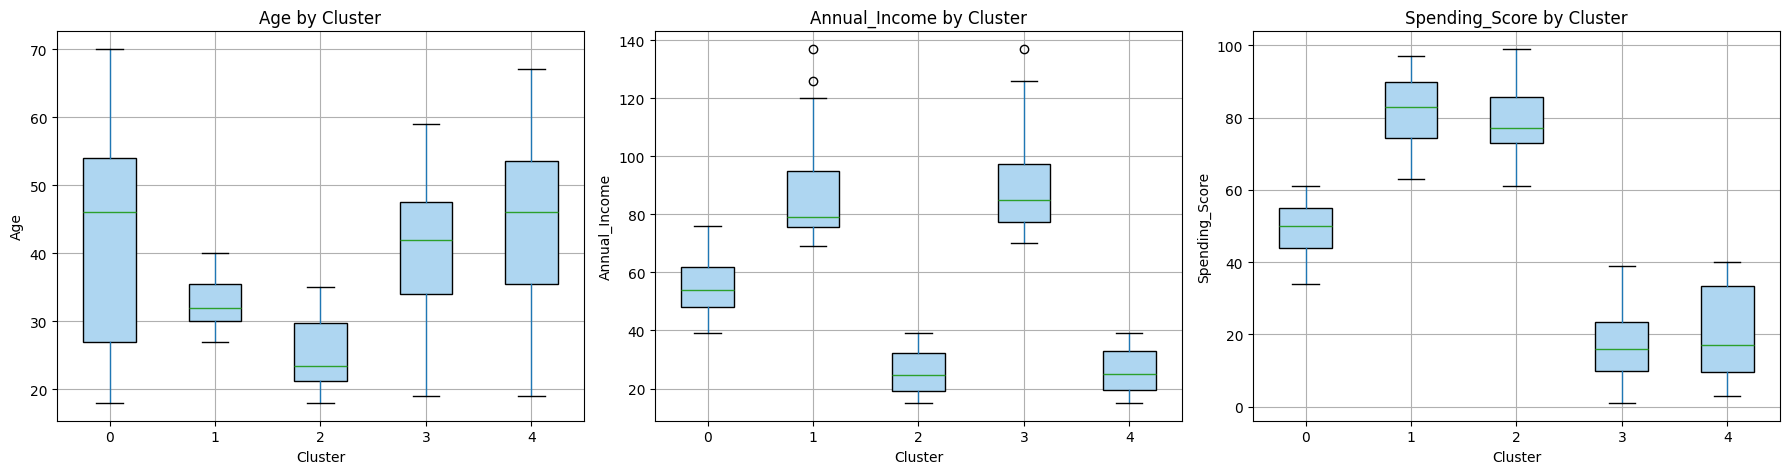

✅ Plot saved: cluster_boxplots.png


In [32]:
# Boxplots per Cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distribution per Cluster', fontsize=14, fontweight='bold')

for idx, feature in enumerate(['Age', 'Annual_Income', 'Spending_Score']):
    df.boxplot(column=feature, by='Cluster', ax=axes[idx],
               patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    axes[idx].set_title(f'{feature} by Cluster')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: cluster_boxplots.png')

In [33]:
#  Cluster Summary Statistics
summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(2)
summary['Customer_Count'] = df['Cluster'].value_counts().sort_index()

print('=== Cluster Summary (Mean Values) ===')
print(summary.to_string())

=== Cluster Summary (Mean Values) ===
           Age  Annual_Income  Spending_Score  Customer_Count
Cluster                                                      
0        42.72          55.30           49.52              81
1        32.69          86.54           82.13              39
2        25.27          25.73           79.36              22
3        41.11          88.20           17.11              35
4        45.22          26.30           20.91              23


In [34]:
#   Business Insights
insights = {
    0: ('Low Income, Low Spend',   'Budget-conscious, careful shoppers',     'Offer discounts & value deals'),
    1: ('High Income, Low Spend',  'Rich but reluctant spenders',            'Premium loyalty reward programs'),
    2: ('Medium Income, Medium Spend', 'Average balanced shoppers',          'General promotions & seasonal offers'),
    3: ('Low Income, High Spend',  'Impulsive spenders with low income',     'Budget-friendly trendy products'),
    4: ('High Income, High Spend', '⭐ Ideal VIP customers — highest value', 'Exclusive VIP programs & early access'),
}

print('=== Business Insights per Cluster ===\n')
print(f'{"Cluster":<10}{"Profile":<35}{"Description":<40}{"Strategy"}')
print('-' * 120)
for cluster_id, (profile, desc, strategy) in insights.items():
    print(f'{cluster_id:<10}{profile:<35}{desc:<40}{strategy}')

=== Business Insights per Cluster ===

Cluster   Profile                            Description                             Strategy
------------------------------------------------------------------------------------------------------------------------
0         Low Income, Low Spend              Budget-conscious, careful shoppers      Offer discounts & value deals
1         High Income, Low Spend             Rich but reluctant spenders             Premium loyalty reward programs
2         Medium Income, Medium Spend        Average balanced shoppers               General promotions & seasonal offers
3         Low Income, High Spend             Impulsive spenders with low income      Budget-friendly trendy products
4         High Income, High Spend            ⭐ Ideal VIP customers — highest value   Exclusive VIP programs & early access


In [35]:
#Save Clustered Dataset
df.to_csv('Mall_Customers_Clustered.csv', index=False)

print('✅ Clustered dataset saved as: Mall_Customers_Clustered.csv')
print(f'   Total rows: {len(df)}')
print('\nPreview:')
print(df.head(10).to_string())

✅ Clustered dataset saved as: Mall_Customers_Clustered.csv
   Total rows: 200

Preview:
   CustomerID  Gender  Age  Annual_Income  Spending_Score  Cluster
0           1    Male   19             15              39        4
1           2    Male   21             15              81        2
2           3  Female   20             16               6        4
3           4  Female   23             16              77        2
4           5  Female   31             17              40        4
5           6  Female   22             17              76        2
6           7  Female   35             18               6        4
7           8  Female   23             18              94        2
8           9    Male   64             19               3        4
9          10  Female   30             19              72        2
